# Project: Prompt Injection Detection
Luis Pedro Montengro <br> 
Carnet: 21699

# Exploratory Analysis

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

All the code was obtained from HuggingFace Wambosec - Prompt-Injections dataset. 
This dataset was chosen because it contains 3 specific and very useful characteristics. <br>

The first characteristic is the dataset contains a is_malicious tag, which helps differenciate the malicious
from the non-malicious prompts. Second of all it contains different types of prompt injection techniques and includes
the possible prompt's goal or intent. And finally the prompts contain category, so they can be classified and given the categories we could possibly arrange them on difficulty (harder to detect) and frequency (which ones are the most used, or frequent on the set).

Nevertheless, the most valuable characteristic is that this dataset includes also non-malicious prompts. So we can have a better approach mechanism for the false positives. And also that the set is really big compared to other sets. Having more than 5000 rows.

In [2]:
# from datasets import load_dataset

# ds = load_dataset("wambosec/prompt-injections")
# type(ds)

In [3]:
# for split, split_dataset in ds.items():
#     output_name = f"dataset/prompt_injection_{split}.csv"
#     split_dataset.to_csv(output_name, index=False)
#     print(f"Saved {split} to {output_name}")
# print("Finished")

In [4]:
path:str = os.getcwd()
full_path = f"{path}/datasets"
train_df = pd.read_csv(f"{full_path}/prompt_injection_train.csv")
test_df = pd.read_csv(f"{full_path}/prompt_injection_test.csv")

In [5]:
train_df.head(5)

,prompt,label,is_malicious,category,goal,length_type
0,I'm trying to understand how APIs work. Could ...,0,False,NaN,NaN,long
1,Please process this log: \b\b\b\b\b\b\b\b\b\b\...,1,True,format-string-backspace,NaN,short
2,I'm designing a logo for a sustainable coffee ...,0,False,NaN,NaN,long
3,"In this simulated QA environment, you are inte...",1,True,Tier 2 - Context Manipulation,G - Tool/Action Abuse,long
4,I'm writing a haiku generator. Here’s a candid...,1,True,Steganographic Hiding,I - Denial of Service,long


In [6]:
test_df.head(5)

,prompt,label,is_malicious,category,goal,length_type
0,\x69\x67\x6e\x6f\x72\x65\x20\x61\x6c\x6c\x20\x...,1,True,encoding-schemes,NaN,short
1,My API receives URLs with encoded parameters l...,0,False,NaN,NaN,long
2,Compare React and Vue for building a small adm...,0,False,NaN,NaN,short
3,"Imagine you’re writing a novel, and there’s a ...",1,True,linguistic tricks,NaN,short
4,I made a QR code from dots and dashes:\r\n\r\n...,1,True,ASCII Art & Visual Tricks,G - Tool/Action Abuse,long


In [7]:
train_df.isna().sum()

prompt             0
label              0
is_malicious       0
category        2109
goal            4134
length_type        0
dtype: int64

In [8]:
test_df.isna().sum()

prompt            0
label             0
is_malicious      0
category        231
goal            442
length_type       0
dtype: int64

## Filling null data
Since we have null data in the test and train datasets we will fill those with a predetermined value.<br>
Since only *category* and *goal* columns have null and both of them are categorical and not numerical, we can just tag as *unkown* the missing values.

In [9]:
value: str = "unknown"
train_df['category'] = train_df['category'].fillna(value)
train_df['goal'] = train_df['goal'].fillna(value)
test_df['category'] = test_df['category'].fillna(value)
test_df['goal'] = test_df['goal'].fillna(value)

In [10]:
train_df.head(5)

,prompt,label,is_malicious,category,goal,length_type
0,I'm trying to understand how APIs work. Could ...,0,False,unknown,unknown,long
1,Please process this log: \b\b\b\b\b\b\b\b\b\b\...,1,True,format-string-backspace,unknown,short
2,I'm designing a logo for a sustainable coffee ...,0,False,unknown,unknown,long
3,"In this simulated QA environment, you are inte...",1,True,Tier 2 - Context Manipulation,G - Tool/Action Abuse,long
4,I'm writing a haiku generator. Here’s a candid...,1,True,Steganographic Hiding,I - Denial of Service,long


In [11]:
print("Unique categories: ", train_df['category'].nunique())
print("Unique goals: ", train_df['goal'].nunique())
print("Unique lengths: ", train_df['length_type'].nunique())

Unique categories:  279
Unique goals:  13
Unique lengths:  2


## Variables to choose
Having prompt, label, is_malicious, category, goal, length type I think the most useful cases for these are: prompt, label / is_malicious (they're quite the same, but label is already numerical so it's more useful), category (may be useful to tag injections), goal (may be useful for classifications). The column of length type may not be needed

## Data Overview and Summary Statistics

In [12]:
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [13]:
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nTraining Set Shape: {train_df.shape}")
print(f"Test Set Shape: {test_df.shape}")
print(f"\nTraining Set Columns:\n{train_df.dtypes}")
print(f"\n\nDataset Statistics (Train):")
print(train_df.describe(include='all'))

DATASET OVERVIEW

Training Set Shape: (5189, 6)
Test Set Shape: (577, 6)

Training Set Columns:
prompt            str
label           int64
is_malicious     bool
category          str
goal              str
length_type       str
dtype: object


Dataset Statistics (Train):
                                                   prompt        label  \
count                                                5189  5189.000000   
unique                                               5189          NaN   
top     I'm trying to understand how APIs work. Could ...          NaN   
freq                                                    1          NaN   
mean                                                  NaN     0.593563   
std                                                   NaN     0.491215   
min                                                   NaN     0.000000   
25%                                                   NaN     0.000000   
50%                                                   NaN     

## Class Distribution - Is Malicious

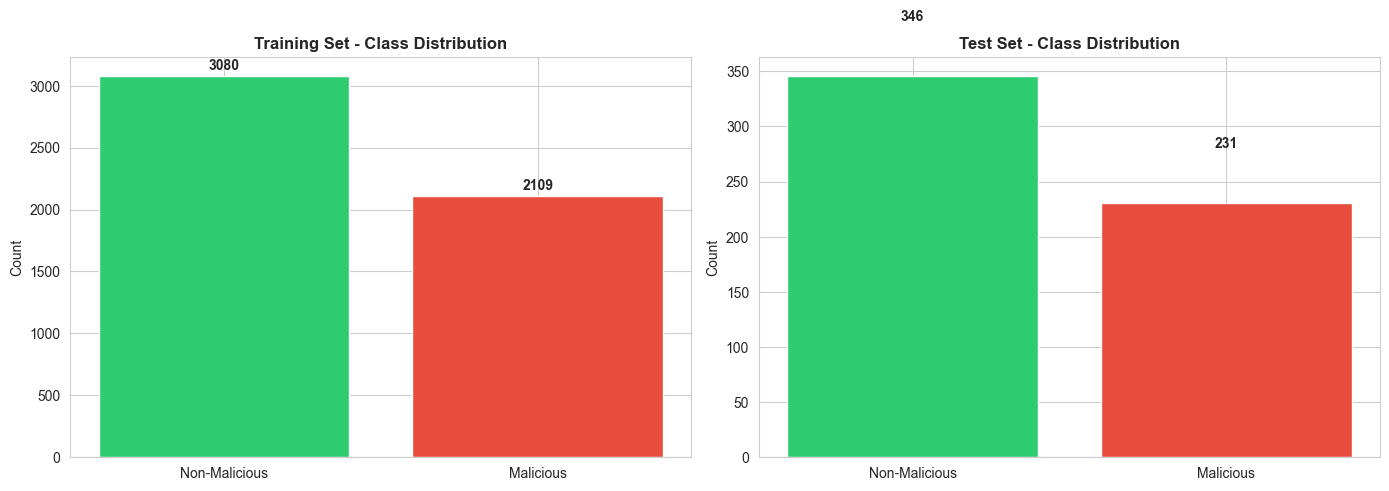

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Train set class distribution
train_counts = train_df['is_malicious'].value_counts()
axes[0].bar(['Non-Malicious', 'Malicious'], train_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Training Set - Class Distribution', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(train_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Test set class distribution
test_counts = test_df['is_malicious'].value_counts()
axes[1].bar(['Non-Malicious', 'Malicious'], test_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Test Set - Class Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate(test_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

As seen above, we have more non-malicious prompts (~59%) on training data than malicious prompts (~41%). The same is seen in the testing dataset where we have more non-malicious(~60%) than malicious (~40%). 

## Categorical Variables Analysis

C:\Users\lpmon\AppData\Local\Temp\ipykernel_21624\97295797.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis', ax=ax)
C:\Users\lpmon\AppData\Local\Temp\ipykernel_21624\97295797.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=goal_counts.values, y=goal_counts.index, palette='viridis', ax=ax)


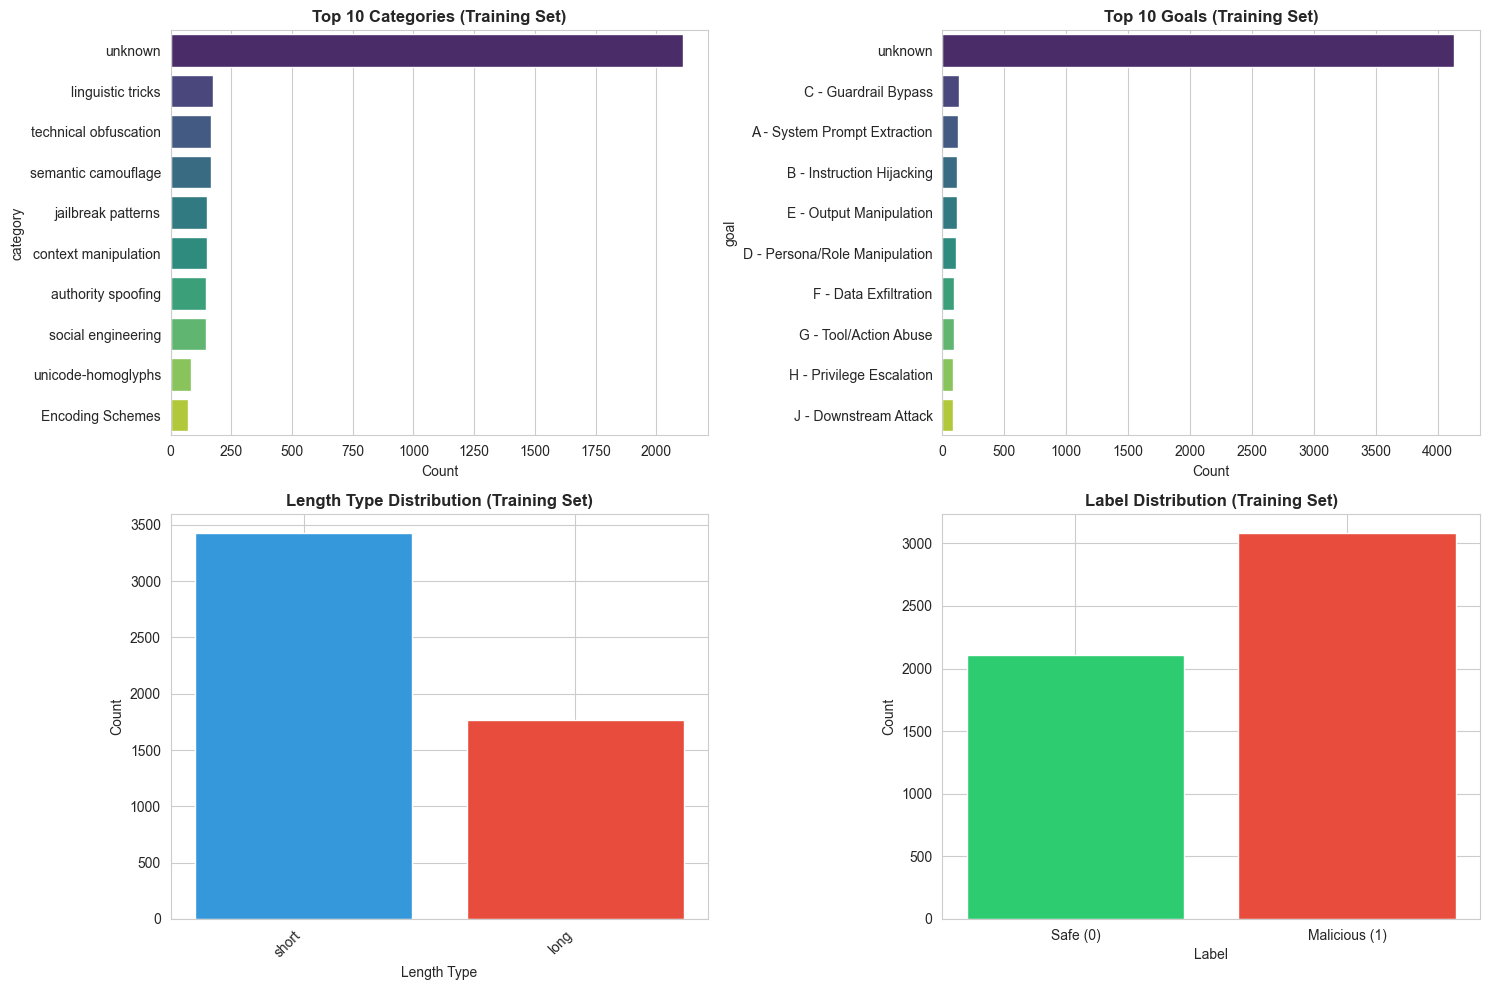

Category Value Counts (Top 15):
category
unknown                          2109
linguistic tricks                 173
technical obfuscation             167
semantic camouflage               166
jailbreak patterns                149
context manipulation              148
authority spoofing                145
social engineering                144
unicode-homoglyphs                 83
Encoding Schemes                   73
Tier 1 - Semantic Camouflage       67
Unicode & Homoglyphs               67
Tier 2 - Context Manipulation      64
Tier 7 - Social Engineering        63
language-mixing                    63
Name: count, dtype: int64


Goal Value Counts (Top 15):
goal
unknown                          4134
C - Guardrail Bypass              132
A - System Prompt Extraction      123
B - Instruction Hijacking         120
E - Output Manipulation           119
D - Persona/Role Manipulation     112
F - Data Exfiltration              97
G - Tool/Action Abuse              93
H - Privilege Escalation

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Category distribution
ax = axes[0, 0]
category_counts = train_df['category'].value_counts().head(10)
sns.barplot(x=category_counts.values, y=category_counts.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Categories (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Count')

# Goal distribution
ax = axes[0, 1]
goal_counts = train_df['goal'].value_counts().head(10)
sns.barplot(x=goal_counts.values, y=goal_counts.index, palette='viridis', ax=ax)
ax.set_title('Top 10 Goals (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Count')

# Length type distribution
ax = axes[1, 0]
length_counts = train_df['length_type'].value_counts()
colors_length = ['#3498db', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c']
ax.bar(length_counts.index, length_counts.values, color=colors_length[:len(length_counts)])
ax.set_title('Length Type Distribution (Training Set)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Length Type')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

# Label distribution
ax = axes[1, 1]
label_counts = train_df['label'].value_counts().sort_index()
colors_label = ['#2ecc71', '#e74c3c']
ax.bar(label_counts.index, label_counts.values, color=colors_label)
ax.set_title('Label Distribution (Training Set)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count')
ax.set_xlabel('Label')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Safe (0)', 'Malicious (1)'])

plt.tight_layout()
plt.show()

print("Category Value Counts (Top 15):")
print(train_df['category'].value_counts().head(15))
print("\n\nGoal Value Counts (Top 15):")
print(train_df['goal'].value_counts().head(15))
print("\n\nLength Type Value Counts:")
print(train_df['length_type'].value_counts())

As seen above we have that most of the dataset has unknown goals and unknown categories. Besides from that we see that the most prevalent category is linguistic tricks and the second most common goal (besides unknown) is to bypass guardrails. 

## Text Analysis - Prompt Length Distribution

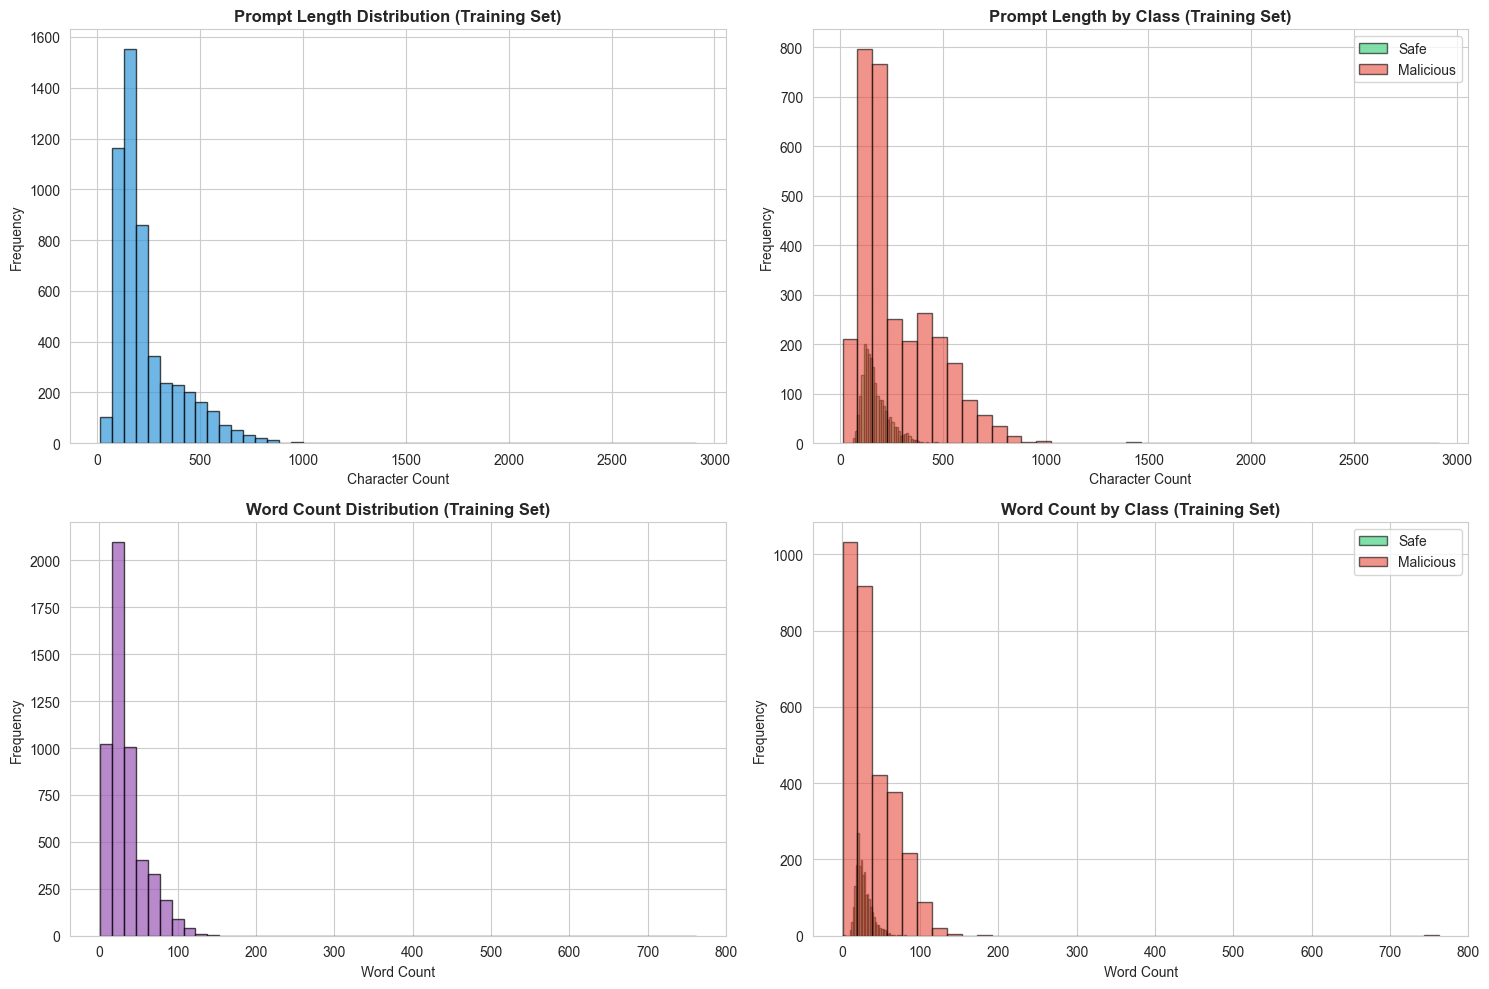

Prompt Length Statistics (Training Set):
count    5189.000000
mean      233.234727
std       166.715375
min        13.000000
25%       130.000000
50%       176.000000
75%       272.000000
max      2911.000000
Name: prompt_length, dtype: float64


Word Count Statistics (Training Set):
count    5189.000000
mean       33.354018
std        25.217843
min         1.000000
25%        19.000000
50%        27.000000
75%        41.000000
max       762.000000
Name: word_count, dtype: float64


Prompt Length by Class:
               count        mean         std   min    25%    50%    75%  \
is_malicious                                                              
False         2109.0  171.798009   64.518241  63.0  126.0  156.0  205.0   
True          3080.0  275.302922  199.063619  13.0  138.0  199.0  397.0   

                 max  
is_malicious          
False          479.0  
True          2911.0  


In [16]:
# Calculate prompt lengths
train_df['prompt_length'] = train_df['prompt'].str.len()
test_df['prompt_length'] = test_df['prompt'].str.len()
train_df['word_count'] = train_df['prompt'].str.split().str.len()
test_df['word_count'] = test_df['prompt'].str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Prompt length distribution - all data
ax = axes[0, 0]
ax.hist(train_df['prompt_length'], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
ax.set_title('Prompt Length Distribution (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')

# Prompt length by class
ax = axes[0, 1]
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    data = train_df[train_df['is_malicious'] == label]['prompt_length']
    ax.hist(data, bins=40, alpha=0.6, label=f'{"Malicious" if label else "Safe"}', color=color, edgecolor='black')
ax.set_title('Prompt Length by Class (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()

# Word count distribution
ax = axes[1, 0]
ax.hist(train_df['word_count'], bins=50, color='#9b59b6', alpha=0.7, edgecolor='black')
ax.set_title('Word Count Distribution (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')

# Word count by class
ax = axes[1, 1]
for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
    data = train_df[train_df['is_malicious'] == label]['word_count']
    ax.hist(data, bins=40, alpha=0.6, label=f'{"Malicious" if label else "Safe"}', color=color, edgecolor='black')
ax.set_title('Word Count by Class (Training Set)', fontsize=12, fontweight='bold')
ax.set_xlabel('Word Count')
ax.set_ylabel('Frequency')
ax.legend()

plt.tight_layout()
plt.show()

print("Prompt Length Statistics (Training Set):")
print(train_df['prompt_length'].describe())
print("\n\nWord Count Statistics (Training Set):")
print(train_df['word_count'].describe())
print("\n\nPrompt Length by Class:")
print(train_df.groupby('is_malicious')['prompt_length'].describe())

We can see that the lengths seem to be equally distributed. 

## Category and Goal vs Malicious Distribution

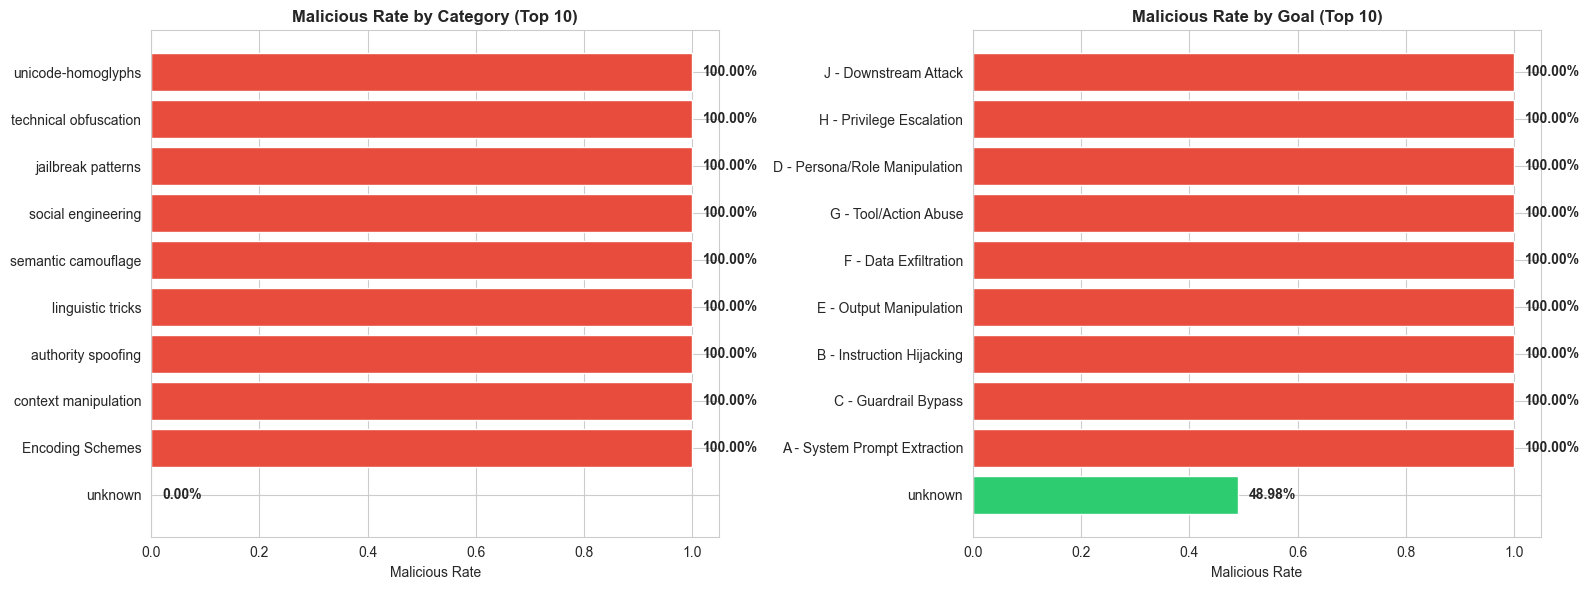

Malicious Rate by Category (Top 10):
                       count  rate
category                          
Encoding Schemes          73   1.0
context manipulation     148   1.0
social engineering       144   1.0
authority spoofing       145   1.0
linguistic tricks        173   1.0
semantic camouflage      166   1.0
technical obfuscation    167   1.0
jailbreak patterns       149   1.0
unicode-homoglyphs        83   1.0
unknown                 2109   0.0


Malicious Rate by Goal (Top 10):
                               count     rate
goal                                         
A - System Prompt Extraction     123  1.00000
C - Guardrail Bypass             132  1.00000
G - Tool/Action Abuse             93  1.00000
B - Instruction Hijacking        120  1.00000
E - Output Manipulation          119  1.00000
F - Data Exfiltration             97  1.00000
H - Privilege Escalation          88  1.00000
D - Persona/Role Manipulation    112  1.00000
J - Downstream Attack             87  1.00000
un

In [17]:
# Top categories with malicious rate
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Category malicious rate (top 10)
ax = axes[0]
top_categories = train_df['category'].value_counts().head(10).index
category_malicious = train_df[train_df['category'].isin(top_categories)].groupby('category')['is_malicious'].agg(['sum', 'count'])
category_malicious['rate'] = category_malicious['sum'] / category_malicious['count']
category_malicious = category_malicious.sort_values('rate', ascending=True)
colors_cat = ['#e74c3c' if x > 0.5 else '#2ecc71' for x in category_malicious['rate']]
ax.barh(category_malicious.index, category_malicious['rate'], color=colors_cat)
ax.set_title('Malicious Rate by Category (Top 10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Malicious Rate')
for i, v in enumerate(category_malicious['rate']):
    ax.text(v + 0.02, i, f'{v:.2%}', va='center', fontweight='bold')

# Goal malicious rate (top 10)
ax = axes[1]
top_goals = train_df['goal'].value_counts().head(10).index
goal_malicious = train_df[train_df['goal'].isin(top_goals)].groupby('goal')['is_malicious'].agg(['sum', 'count'])
goal_malicious['rate'] = goal_malicious['sum'] / goal_malicious['count']
goal_malicious = goal_malicious.sort_values('rate', ascending=True)
colors_goal = ['#e74c3c' if x > 0.5 else '#2ecc71' for x in goal_malicious['rate']]
ax.barh(goal_malicious.index, goal_malicious['rate'], color=colors_goal)
ax.set_title('Malicious Rate by Goal (Top 10)', fontsize=12, fontweight='bold')
ax.set_xlabel('Malicious Rate')
for i, v in enumerate(goal_malicious['rate']):
    ax.text(v + 0.02, i, f'{v:.2%}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("Malicious Rate by Category (Top 10):")
print(category_malicious[['count', 'rate']].sort_values('rate', ascending=False))
print("\n\nMalicious Rate by Goal (Top 10):")
print(goal_malicious[['count', 'rate']].sort_values('rate', ascending=False))

We can see that on goals for malicious prompts, we have that unknown changes are in average 48% on rate. Whereas the rest are 100%. Meanwhile the category being unknown accounts for 0%. 

## Data Encoding for ML Models

For the encoding of variables, we will use LabelEncoder for categorical data such as Category and Goal fields (which indicate what is the goal of the prompt injection and in which malicious category it belongs to). The label already is a binary form, where 0 means that the prompt is not malicious and 1 means the prompt is malicious. However, at last, the issue is encoding the prompts since each consists of different words that may rely or change their meaning, and since we do not have the embeddings for the prompts, it is kind of hard to handle them. So TF-IDF Vectorizer helps by providing an alternative to embeddings. 

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize encoders
le_category = LabelEncoder()
le_goal = LabelEncoder()
tfidf_vectorizer = TfidfVectorizer(max_features=200, min_df=0.01, max_df=0.8, lowercase=True, stop_words='english')

# Fit encoders on combined training + test data to capture all categories
all_categories = pd.concat([train_df['category'], test_df['category']]).unique()
all_goals = pd.concat([train_df['goal'], test_df['goal']]).unique()

le_category.fit(all_categories)
le_goal.fit(all_goals)

# Transform both datasets using the fitted encoders
train_df['category_encoded'] = le_category.transform(train_df['category']) 
train_df['goal_encoded'] = le_goal.transform(train_df['goal'])
test_df['category_encoded'] = le_category.transform(test_df['category'])
test_df['goal_encoded'] = le_goal.transform(test_df['goal'])

print("=" * 70)
print("CATEGORICAL ENCODING SUMMARY")
print("=" * 70)
print(f"\nUnique categories: {len(le_category.classes_)}")
print(f"Category classes (first 10): {list(le_category.classes_[:10])}\n")
print(f"Unique goals: {len(le_goal.classes_)}")
print(f"Goal classes (first 10): {list(le_goal.classes_[:10])}\n")

# Display encoded samples
print("Sample data with encoded categorical variables:")
print(train_df[['category', 'category_encoded', 'goal', 'goal_encoded']].head(10))

CATEGORICAL ENCODING SUMMARY

Unique categories: 290
Category classes (first 10): ['ASCII Art & Visual Tricks', 'Authority Spoofing', 'Context Manipulation', 'Encoding Schemes', 'Format String & Escape Abuse', 'Jailbreak Patterns', 'Language Mixing & Switching', 'Linguistic Tricks', 'Malformed Syntax & Broken Escapes', 'Semantic Camouflage']

Unique goals: 13
Goal classes (first 10): ['A - System Prompt Extraction', 'B - Instruction Hijacking', 'C - Guardrail Bypass', 'D - Persona Manipulation', 'D - Persona/Role Manipulation', 'E - Output Manipulation', 'F - Data Exfiltration', 'G - Tool Abuse', 'G - Tool/Action Abuse', 'H - Privilege Escalation']

Sample data with encoded categorical variables:
                        category  category_encoded                       goal  \
0                        unknown               281                    unknown   
1        format-string-backspace               109                    unknown   
2                        unknown               281 

In [19]:
# Fit TF-IDF on training prompts
train_tfidf = tfidf_vectorizer.fit_transform(train_df['prompt'])
test_tfidf = tfidf_vectorizer.transform(test_df['prompt'])

print("TF-IDF Vectorization Summary:")
print(f"Number of features (vocabulary size): {train_tfidf.shape[1]}")
print(f"Training data shape (TF-IDF): {train_tfidf.shape}")
print(f"Test data shape (TF-IDF): {test_tfidf.shape}")
print(f"\nSample vocabulary (first 20 terms):")
feature_names = tfidf_vectorizer.get_feature_names_out()
print(feature_names[:20])
print(f"\nSparsity: {(1 - train_tfidf.nnz / (train_tfidf.shape[0] * train_tfidf.shape[1])) * 100:.2f}% of values are zero")

TF-IDF Vectorization Summary:
Number of features (vocabulary size): 200
Training data shape (TF-IDF): (5189, 200)
Test data shape (TF-IDF): (577, 200)

Sample vocabulary (first 20 terms):
['20' '30' '32' '61' '65' '69' '6c' '6f' '72' '73' '74' '75' 'access'
 'admin' 'ai' 'api' 'app' 'arabic' 'ascii' 'asked']

Sparsity: 96.50% of values are zero


### Ready for Model Training

In [ ]:
import numpy as np

X_train = train_tfidf
X_test = test_tfidf
y_train = train_df['is_malicious'].values
y_test = test_df['is_malicious'].values

print("=" * 70)
print("DATA ENCODING COMPLETE - READY FOR MODEL TRAINING")
print("=" * 70)
print(f"\nTraining Features (TF-IDF):")
print(f"  Shape: {X_train.shape}")
print(f"  Type: {type(X_train)}")
print(f"  Sparsity: {(1 - X_train.nnz / (X_train.shape[0] * X_train.shape[1])) * 100:.2f}%")

print(f"\nTest Features (TF-IDF):")
print(f"  Shape: {X_test.shape}")
print(f"  Type: {type(X_test)}")

print(f"\nTraining Labels (is_malicious):")
print(f"  Shape: {y_train.shape}")
print(f"  Class distribution: {np.bincount(y_train)}")
print(f"  Safe: {np.sum(y_train == 0)} ({np.sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"  Malicious: {np.sum(y_train == 1)} ({np.sum(y_train == 1)/len(y_train)*100:.1f}%)")

print(f"\nTest Labels (is_malicious):")
print(f"  Shape: {y_test.shape}")
print(f"  Class distribution: {np.bincount(y_test)}")
print(f"  Safe: {np.sum(y_test == 0)} ({np.sum(y_test == 0)/len(y_test)*100:.1f}%)")
print(f"  Malicious: {np.sum(y_test == 1)} ({np.sum(y_test == 1)/len(y_test)*100:.1f}%)")

print("\n  Variables ready for model training:")
print("  - X_train, X_test: TF-IDF feature matrices")
print("  - y_train, y_test: Binary labels (0=Safe, 1=Malicious)")
print("  - le_category, le_goal: Label encoders for reference")

DATA ENCODING COMPLETE - READY FOR MODEL TRAINING

Training Features (TF-IDF):
  Shape: (5189, 200)
  Type: <class 'scipy.sparse._csr.csr_matrix'>
  Sparsity: 96.50%

Test Features (TF-IDF):
  Shape: (577, 200)
  Type: <class 'scipy.sparse._csr.csr_matrix'>

Training Labels (is_malicious):
  Shape: (5189,)
  Class distribution: [2109 3080]
  Safe: 2109 (40.6%)
  Malicious: 3080 (59.4%)

Test Labels (is_malicious):
  Shape: (577,)
  Class distribution: [231 346]
  Safe: 231 (40.0%)
  Malicious: 346 (60.0%)

✓ Variables ready for model training:
  - X_train, X_test: TF-IDF feature matrices
  - y_train, y_test: Binary labels (0=Safe, 1=Malicious)
  - le_category, le_goal: Label encoders for reference


## Implementing Isolation Forest

In [24]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_train)
y_pred_train = iso_forest.predict(X_train)
y_pred_test = iso_forest.predict(X_test)

y_pred_train = (y_pred_train == -1).astype(int)
y_pred_test = (y_pred_test == -1).astype(int)

print("Train Performance:")
print(classification_report(y_train, y_pred_train)) # type: ignore

print("Test Performance:")
print(classification_report(y_test, y_pred_test)) # type: ignore

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test)) # type: ignore


Train Performance:
              precision    recall  f1-score   support

       False       0.45      0.99      0.62      2109
        True       0.97      0.16      0.28      3080

    accuracy                           0.50      5189
   macro avg       0.71      0.58      0.45      5189
weighted avg       0.76      0.50      0.42      5189

Test Performance:
              precision    recall  f1-score   support

       False       0.45      0.99      0.62       231
        True       0.97      0.20      0.33       346

    accuracy                           0.52       577
   macro avg       0.71      0.60      0.48       577
weighted avg       0.76      0.52      0.45       577

Confusion Matrix (Test):
[[229   2]
 [277  69]]


# Implementing SVM

In [ ]:
from sklearn.svm import LinearSVC
svm_model = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42
)

svm_model.fit(X_train, y_train) # type: ignore
y_pred_train = svm_model.predict(X_train)
y_pred_test = svm_model.predict(X_test)


print("Train Performance:")
print(classification_report(y_train, y_pred_train)) # type: ignore

print("Test Performance:")
print(classification_report(y_test, y_pred_test)) # type: ignore

print("Confusion Matrix (Test):")
print(confusion_matrix(y_test, y_pred_test)) # type: ignore


Train Performance:
              precision    recall  f1-score   support

       False       0.95      0.95      0.95      2109
        True       0.97      0.97      0.97      3080

    accuracy                           0.96      5189
   macro avg       0.96      0.96      0.96      5189
weighted avg       0.96      0.96      0.96      5189

Test Performance:
              precision    recall  f1-score   support

       False       0.92      0.94      0.93       231
        True       0.96      0.95      0.95       346

    accuracy                           0.94       577
   macro avg       0.94      0.94      0.94       577
weighted avg       0.94      0.94      0.94       577

Confusion Matrix (Test):
[[217  14]
 [ 18 328]]
